In [5]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from scipy import stats 
from scipy.stats import pearsonr
from scipy.stats import skew, kurtosis

In [18]:
df = pd.read_csv("sleep_health_dataset.csv")

styled_df = (
    df.head(10)
    .style
    .format(precision=2)
    .set_caption("Preview Dataset Sleep Health")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "18px"),
                ("font-weight", "600"),
                ("color", "#1E3A5F"),
                ("text-align", "left"),
                ("padding", "12px 0")
            ]
        },

        {
            "selector": "th",
            "props": [
                ("background-color", "#DCEEFB"),
                ("color", "#1E3A5F"),
                ("font-size", "12px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border-bottom", "1px solid #BFDBFE")
            ]
        },

        
        {
            "selector": "td",
            "props": [
                ("padding", "8px"),
                ("font-size", "12px"),
                ("color", "#374151"),
                ("border-bottom", "1px solid #E5F3FF"),
                ("background-color", "#F8FCFF")
            ]
        },

    
        {
            "selector": "tr:hover td",
            "props": [
                ("background-color", "#E0F2FE")
            ]
        }
    ])
)

styled_df

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.70,Japan,6.19,6.60,22.50,19.30,16,3,0,0.00,32,0,6592,0,4.40,10.70,Morning,Healthy,63,0,0,20.10,1.84,Autumn,Weekday,73.40,Healthy,0
1,2,55,Female,Software Engineer,22.00,USA,8.32,6.90,26.90,14.90,17,4,0,0.00,33,1,10111,8,4.00,3.00,Neutral,Healthy,52,1,0,18.00,0.13,Winter,Weekend,99.40,Healthy,1
2,3,42,Male,Nurse,25.00,India,3.74,1.00,20.20,16.20,26,4,0,2.00,89,1,9222,28,7.80,3.60,Neutral,Both,72,0,1,17.90,1.67,Spring,Weekend,2.50,Severe,0
3,4,37,Female,Student,29.50,India,6.79,6.40,17.70,17.70,13,4,0,1.00,52,1,9190,40,4.90,6.70,Morning,Healthy,71,0,0,19.10,2.37,Summer,Weekend,67.80,Healthy,0
4,5,23,Male,Lawyer,23.60,Spain,5.02,3.20,23.30,18.30,30,5,40,0.00,72,0,4273,0,7.40,10.40,Neutral,Healthy,71,0,0,19.70,1.26,Summer,Weekday,38.10,Mild,0
5,6,23,Female,Driver,25.50,Brazil,8.16,5.70,17.30,20.10,29,2,150,2.00,72,0,9170,0,5.50,6.20,Neutral,Depression,71,1,0,22.70,0.70,Summer,Weekend,49.90,Mild,1
6,7,20,Female,Software Engineer,18.20,Netherlands,7.27,5.10,17.50,18.80,31,2,0,3.00,148,1,10786,0,5.00,4.30,Evening,Anxiety,79,0,0,17.60,0.73,Spring,Weekend,57.90,Mild,1
7,8,48,Female,Freelancer,31.50,UK,8.04,6.50,25.30,22.30,22,4,150,0.00,59,1,6194,46,5.50,2.80,Neutral,Anxiety,60,1,0,21.60,0.47,Winter,Weekend,92.00,Mild,0
8,9,37,Male,Manager,29.90,USA,6.04,5.40,18.90,15.70,37,0,400,0.00,40,0,6083,44,6.00,5.40,Neutral,Anxiety,74,0,0,17.80,1.80,Autumn,Weekend,53.60,Mild,0
9,10,41,Female,Nurse,34.80,USA,6.22,4.90,21.40,15.50,24,3,0,0.00,88,0,5207,0,5.70,12.70,Evening,Healthy,80,1,0,24.40,1.51,Autumn,Weekday,67.80,Mild,1


In [26]:

missing = (
    df.isnull()
      .sum()
      .to_frame(name="Jumlah Missing")
      .style
      .background_gradient(cmap="Blues")
      .format("{:.0f}")
      .set_caption("Pemeriksaan Missing Value")
      .set_table_styles([

       
          {
              "selector": "caption",
              "props": [
                  ("font-size", "18px"),
                  ("font-weight", "bold"),
                  ("color", "#1E3A5F"),
                  ("text-align", "left"),
                  ("padding", "12px 0")
              ]
          },

          
          {
              "selector": "th",
              "props": [
                  ("background-color", "#DCEEFB"),
                  ("color", "#1E3A5F"),
                  ("font-size", "12px"),
                  ("font-weight", "bold"),
                  ("padding", "10px"),
                  ("border-bottom", "1px solid #BFDBFE"),
                   ("text-align", "left")
              ]
          },

      
          {
              "selector": "td",
              "props": [
                  ("background-color", "#F8FCFF"),
                  ("color", "#374151"),
                  ("font-size", "12px"),
                  ("padding", "8px"),
                  ("border-bottom", "1px solid #E5F3FF"),
                   ("text-align", "left")
              ]
          },

          
          {
              "selector": "tr:hover td",
              "props": [
                  ("background-color", "#E0F2FE"),
                  
              ]
          }
      ])
)

missing

,Jumlah Missing
person_id,0
age,0
gender,0
occupation,0
bmi,0
country,0
sleep_duration_hrs,0
sleep_quality_score,0
rem_percentage,0
deep_sleep_percentage,0


In [55]:

duplicate_count = df.duplicated().sum()

duplicate_table = pd.DataFrame({
    "Pemeriksaan": ["Data Duplikat"],
    "Jumlah": [duplicate_count]
})

# Styling tabel
styled_duplicate = (
    duplicate_table.style
    .hide(axis="index")
    .background_gradient(cmap="Blues", subset=["Jumlah"])
    .format({"Jumlah": "{:.0f}"})
    .set_caption("Pemeriksaan Data Duplikat")
    .set_table_styles([

        # Judul
        {
            "selector": "caption",
            "props": [
                ("font-size", "12px"),
                ("font-weight", "bold"),
                ("color", "#1E3A5F"),
                ("text-align", "left"),
                ("padding", "12px 0")
            ]
        },

        # Header
        {
            "selector": "th",
            "props": [
                ("background-color", "#DCEEFB"),
                ("color", "#1E3A5F"),
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border-bottom", "1px solid #BFDBFE"),
                ("text-align", "center")
            ]
        },

        # Isi tabel
        {
            "selector": "td",
            "props": [
                ("background-color", "#F8FCFF"),
                ("color", "#374151"),
                ("font-size", "13px"),
                ("padding", "8px"),
                ("border-bottom", "1px solid #E5F3FF"),
                ("text-align", "center")
            ]
        },

        # Hover
        {
            "selector": "tr:hover td",
            "props": [
                ("background-color", "#E0F2FE")
            ]
        }
    ])
)

styled_duplicate

Pemeriksaan,Jumlah
Data Duplikat,0


In [45]:

cols = pd.DataFrame({
    "No": range(1, len(df.columns) + 1),
    "Nama Kolom": df.columns
})

styled_cols = (
    cols.style
    .hide(axis="index")
    .set_caption("Daftar Kolom Dataset")
    .set_table_styles([

        
        {
            "selector": "caption",
            "props": [
                ("font-size", "12px"),
                ("font-weight", "bold"),
                ("color", "#1E3A5F"),
                ("text-align", "left"),
                ("padding", "12px 0")
            ]
        },

       
        {
            "selector": "th",
            "props": [
                ("background-color", "#DCEEFB"),
                ("color", "#1E3A5F"),
                ("font-size", "12px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border-bottom", "1px solid #BFDBFE"),
                ("text-align", "center")
            ]
        },

       
        {
            "selector": "td",
            "props": [
                ("background-color", "#F8FCFF"),
                ("color", "#374151"),
                ("font-size", "12px"),
                ("padding", "8px"),
                ("border-bottom", "1px solid #E5F3FF"),
                ("text-align", "left")
            ]
        },

        {
            "selector": "tr:hover td",
            "props": [
                ("background-color", "#E0F2FE")
            ]
        }
    ])
)

styled_cols

No,Nama Kolom
1,person_id
2,age
3,gender
4,occupation
5,bmi
6,country
7,sleep_duration_hrs
8,sleep_quality_score
9,rem_percentage
10,deep_sleep_percentage


In [52]:
# Statistik Deskriptif - Tema Biru Muda

stats = df["sleep_duration_hrs"].describe()

styled_stats = (
    stats
    .to_frame(name="Nilai")
    .style
    .background_gradient(cmap="Blues")
    .format("{:.2f}")
    .set_caption("Statistik Deskriptif Jam Tidur")
    .set_table_styles([

        # Judul
        {
            "selector": "caption",
            "props": [
                ("font-size", "12px"),
                ("font-weight", "bold"),
                ("color", "#1E3A5F"),
                ("text-align", "left"),
                ("padding", "12px 0")
            ]
        },

        # Header
        {
            "selector": "th",
            "props": [
                ("background-color", "#DCEEFB"),
                ("color", "#1E3A5F"),
                ("font-size", "13px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border-bottom", "1px solid #BFDBFE"),
                ("text-align", "center")
            ]
        },

        # Isi tabel
        {
            "selector": "td",
            "props": [
                ("background-color", "#F8FCFF"),
                ("color", "#374151"),
                ("font-size", "13px"),
                ("padding", "8px"),
                ("border-bottom", "1px solid #E5F3FF"),
                ("text-align", "center")
            ]
        },

        # Hover effect
        {
            "selector": "tr:hover td",
            "props": [
                ("background-color", "#E0F2FE")
            ]
        }
    ])
)

styled_stats

,Nilai
count,100000.00
mean,6.42
std,1.27
min,3.00
25%,5.53
50%,6.36
75%,7.27
max,10.50


In [46]:

stats_table = pd.DataFrame({
    "Statistik": ["Mean", "Median", "Mode"],
    "Nilai": [
        df["sleep_duration_hrs"].mean(),
        df["sleep_duration_hrs"].median(),
        df["sleep_duration_hrs"].mode()[0]
    ]
})


styled_stats = (
    stats_table.style
    .hide(axis="index")
    .format({"Nilai": "{:.2f}"})
    .set_caption("Statistik Jam Tidur")
    .set_table_styles([

       
        {
            "selector": "caption",
            "props": [
                ("font-size", "12px"),
                ("font-weight", "bold"),
                ("color", "#1E3A5F"),
                ("text-align", "left"),
                ("padding", "12px 0")
            ]
        },

       
        {
            "selector": "th",
            "props": [
                ("background-color", "#DCEEFB"),
                ("color", "#1E3A5F"),
                ("font-size", "12px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border-bottom", "1px solid #BFDBFE"),
                ("text-align", "center")
            ]
        },

    
        {
            "selector": "td",
            "props": [
                ("background-color", "#F8FCFF"),
                ("color", "#374151"),
                ("font-size", "12px"),
                ("padding", "8px"),
                ("border-bottom", "1px solid #E5F3FF"),
                ("text-align", "center")
            ]
        },

        
        {
            "selector": "tr:hover td",
            "props": [
                ("background-color", "#E0F2FE")
            ]
        }
    ])
)

styled_stats

Statistik,Nilai
Mean,6.42
Median,6.36
Mode,5.93


In [47]:

range_data = df["sleep_duration_hrs"].max() - df["sleep_duration_hrs"].min()
std_dev = df["sleep_duration_hrs"].std()


spread_table = pd.DataFrame({
    "Statistik": ["Range", "Standar Deviasi"],
    "Nilai": [range_data, std_dev]
})


styled_spread = (
    spread_table.style
    .hide(axis="index")
    .format({"Nilai": "{:.2f}"})
    .set_caption("Statistik Penyebaran Jam Tidur")
    .set_table_styles([

        
        {
            "selector": "caption",
            "props": [
                ("font-size", "12px"),
                ("font-weight", "bold"),
                ("color", "#1E3A5F"),
                ("text-align", "left"),
                ("padding", "12px 0")
            ]
        },

        
        {
            "selector": "th",
            "props": [
                ("background-color", "#DCEEFB"),
                ("color", "#1E3A5F"),
                ("font-size", "12px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
                ("border-bottom", "1px solid #BFDBFE"),
                ("text-align", "center")
            ]
        },

 
        {
            "selector": "td",
            "props": [
                ("background-color", "#F8FCFF"),
                ("color", "#374151"),
                ("font-size", "12px"),
                ("padding", "8px"),
                ("border-bottom", "1px solid #E5F3FF"),
                ("text-align", "center")
            ]
        },

       
        {
            "selector": "tr:hover td",
            "props": [
                ("background-color", "#E0F2FE")
            ]
        }
    ])
)

styled_spread

Statistik,Nilai
Range,7.50
Standar Deviasi,1.27


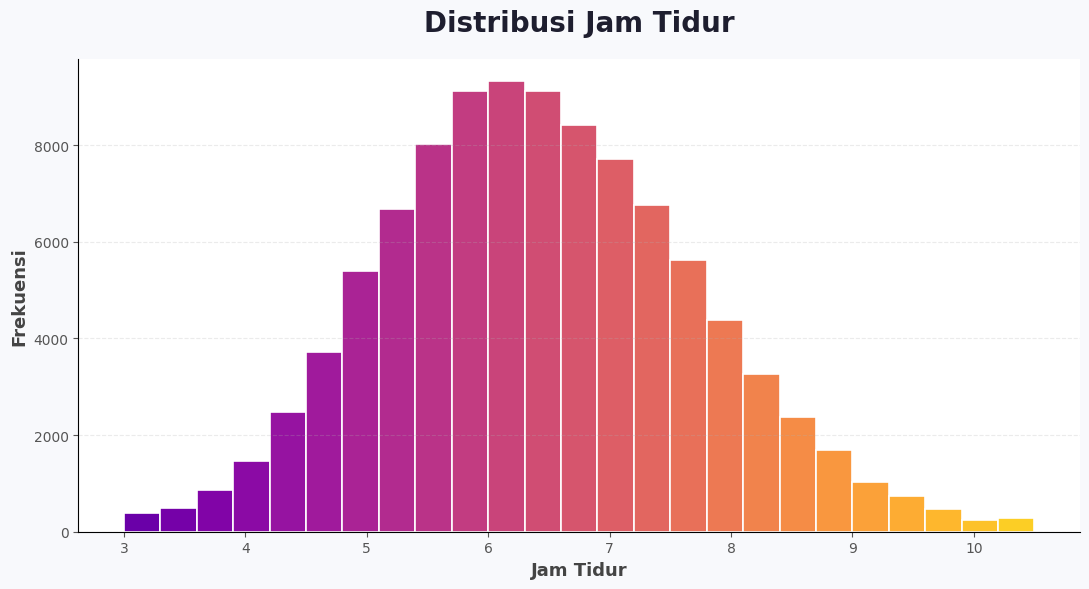

In [48]:

fig, ax = plt.subplots(figsize=(11, 6), facecolor="#f8f9fc")


n, bins, patches = ax.hist(
    df["sleep_duration_hrs"],
    bins=25,
    edgecolor="white",
    linewidth=1.2
)


colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(patches)))

for color, patch in zip(colors, patches):
    patch.set_facecolor(color)


ax.set_title(
    "Distribusi Jam Tidur",
    fontsize=20,
    fontweight="bold",
    color="#1e1e2f",
    pad=20
)


ax.set_xlabel(
    "Jam Tidur",
    fontsize=13,
    fontweight="bold",
    color="#444"
)

ax.set_ylabel(
    "Frekuensi",
    fontsize=13,
    fontweight="bold",
    color="#444"
)


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)


ax.set_facecolor("#ffffff")

# Hilangkan garis tidak perlu
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


ax.tick_params(colors="#555")

plt.tight_layout()
plt.show()


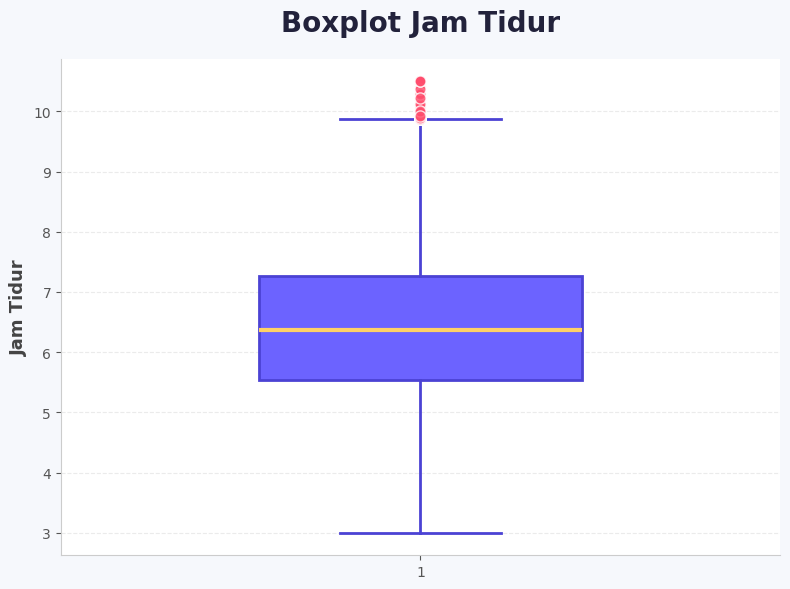

In [49]:

fig, ax = plt.subplots(figsize=(8, 6), facecolor="#f6f8fc")


box = ax.boxplot(
    df["sleep_duration_hrs"],
    patch_artist=True,
    widths=0.45,

    boxprops=dict(
        facecolor="#6C63FF",
        edgecolor="#4B42D4",
        linewidth=2
    ),

    medianprops=dict(
        color="#FFD166",
        linewidth=3
    ),

    whiskerprops=dict(
        color="#4B42D4",
        linewidth=2
    ),

    capprops=dict(
        color="#4B42D4",
        linewidth=2
    ),

    flierprops=dict(
        marker='o',
        markerfacecolor="#FF4D6D",
        markeredgecolor="white",
        markersize=8,
        alpha=0.8
    )
)


ax.set_facecolor("#ffffff")


ax.set_title(
    "Boxplot Jam Tidur",
    fontsize=20,
    fontweight="bold",
    color="#22223B",
    pad=20
)


ax.set_ylabel(
    "Jam Tidur",
    fontsize=13,
    fontweight="bold",
    color="#444"
)


ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')


ax.tick_params(colors="#555")

plt.tight_layout()
plt.show()

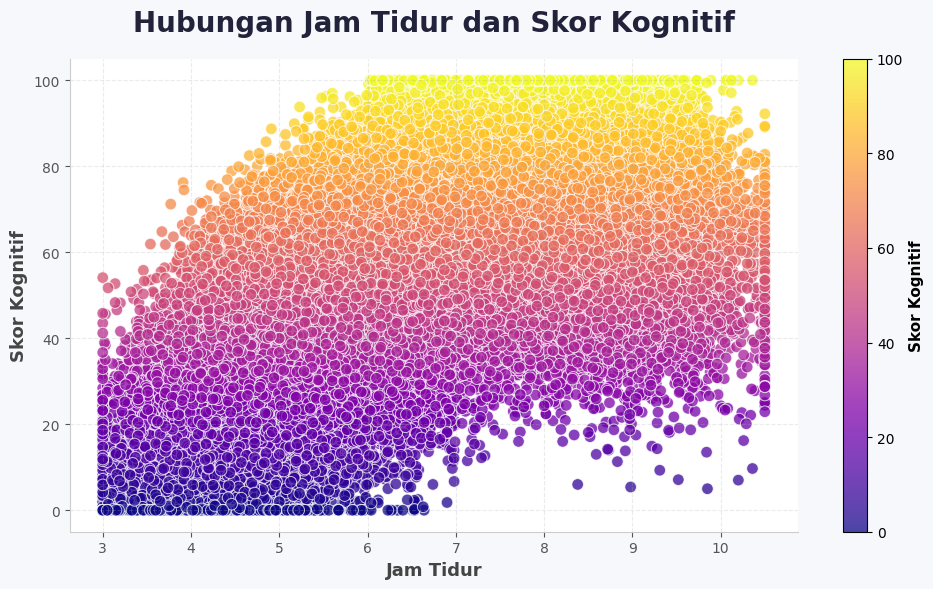

In [50]:

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#f6f8fc")


colors = df["cognitive_performance_score"]

scatter = ax.scatter(
    df["sleep_duration_hrs"],
    df["cognitive_performance_score"],

    c=colors,
    cmap="plasma",

    s=70,
    alpha=0.75,

    edgecolors="white",
    linewidths=0.7
)

ax.set_facecolor("#ffffff")

ax.set_title(
    "Hubungan Jam Tidur dan Skor Kognitif",
    fontsize=20,
    fontweight="bold",
    color="#22223B",
    pad=20
)

ax.set_xlabel(
    "Jam Tidur",
    fontsize=13,
    fontweight="bold",
    color="#444"
)

ax.set_ylabel(
    "Skor Kognitif",
    fontsize=13,
    fontweight="bold",
    color="#444"
)

ax.grid(
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")

ax.tick_params(colors="#555")

cbar = plt.colorbar(scatter)
cbar.set_label(
    "Skor Kognitif",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()
plt.show()